In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

data = pd.read_csv("HomeC.xls")

data.columns = data.columns.str.strip()

print("Dataset loaded successfully")
print("Shape:", data.shape)

data.head()

Dataset loaded successfully
Shape: (108793, 32)


C:\Users\DELL\AppData\Local\Temp\ipykernel_2484\1926119625.py:3: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("HomeC.xls")


,time,use [kW],gen [kW],House overall [kW],Dishwasher [kW],Furnace 1 [kW],Furnace 2 [kW],Home office [kW],Fridge [kW],Wine cellar [kW],...,visibility,summary,apparentTemperature,pressure,windSpeed,cloudCover,windBearing,precipIntensity,dewPoint,precipProbability
0,1451624400,0.932833,0.003483,0.932833,0.000033,0.020700,0.061917,0.442633,0.124150,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
1,1451624401,0.934333,0.003467,0.934333,0.000000,0.020717,0.063817,0.444067,0.124000,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
2,1451624402,0.931817,0.003467,0.931817,0.000017,0.020700,0.062317,0.446067,0.123533,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
3,1451624403,1.022050,0.003483,1.022050,0.000017,0.106900,0.068517,0.446583,0.123133,0.006983,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0
4,1451624404,1.139400,0.003467,1.139400,0.000133,0.236933,0.063983,0.446533,0.122850,0.006850,...,10.0,Clear,29.26,1016.91,9.18,cloudCover,282.0,0.0,24.4,0.0


In [3]:
print("Dataset Information:")
data.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108793 entries, 0 to 108792
Data columns (total 32 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   time                 108793 non-null  int64  
 1   use [kW]             108793 non-null  float64
 2   gen [kW]             108793 non-null  float64
 3   House overall [kW]   108793 non-null  float64
 4   Dishwasher [kW]      108793 non-null  float64
 5   Furnace 1 [kW]       108793 non-null  float64
 6   Furnace 2 [kW]       108793 non-null  float64
 7   Home office [kW]     108793 non-null  float64
 8   Fridge [kW]          108793 non-null  float64
 9   Wine cellar [kW]     108792 non-null  float64
 10  Garage door [kW]     108792 non-null  float64
 11  Kitchen 12 [kW]      108792 non-null  float64
 12  Kitchen 14 [kW]      108792 non-null  float64
 13  Kitchen 38 [kW]      108792 non-null  float64
 14  Barn [kW]            108792 non-null  float64
 

In [4]:
numeric_data = data.select_dtypes(include=[np.number])

print("Numeric Columns:")
print(numeric_data.columns)

Numeric Columns:
Index(['time', 'use [kW]', 'gen [kW]', 'House overall [kW]', 'Dishwasher [kW]',
       'Furnace 1 [kW]', 'Furnace 2 [kW]', 'Home office [kW]', 'Fridge [kW]',
       'Wine cellar [kW]', 'Garage door [kW]', 'Kitchen 12 [kW]',
       'Kitchen 14 [kW]', 'Kitchen 38 [kW]', 'Barn [kW]', 'Well [kW]',
       'Microwave [kW]', 'Living room [kW]', 'Solar [kW]', 'temperature',
       'humidity', 'visibility', 'apparentTemperature', 'pressure',
       'windSpeed', 'windBearing', 'precipIntensity', 'dewPoint',
       'precipProbability'],
      dtype='object')


In [5]:
z_scores = np.abs(stats.zscore(numeric_data))

print("Z-Score Matrix Shape:", z_scores.shape)

Z-Score Matrix Shape: (108793, 29)


In [6]:
threshold = 3

filtered_data = data[(z_scores < threshold).all(axis=1)]

print("Original Dataset Size:", data.shape)
print("Dataset After Removing Outliers:", filtered_data.shape)

Original Dataset Size: (108793, 32)
Dataset After Removing Outliers: (0, 32)


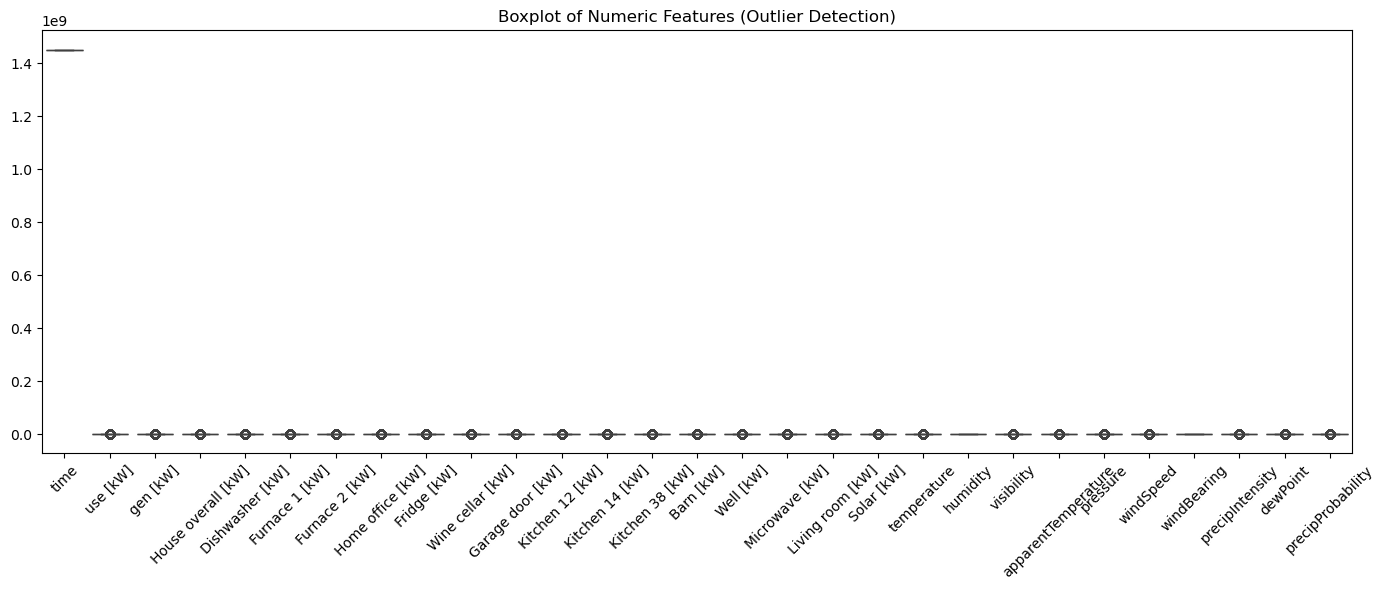

In [7]:


plt.figure(figsize=(14,6))

sns.boxplot(data=numeric_data)

plt.xticks(rotation=45)
plt.title("Boxplot of Numeric Features (Outlier Detection)")
plt.tight_layout()

plt.show()